In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import os
import matplotlib as mpl
import matplotlib.gridspec as gridspec

plt.rcParams.update(plt.rcParamsDefault)
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "legend.frameon": False,
    "savefig.format": "pdf",
    "savefig.bbox": "tight",
    "xtick.top": True,
    "ytick.right": True,
})

In [2]:
# =================================================================
# 0. SIMULATION CONSTANTS
# =================================================================
N_PARTICLES = 512
data_dir = "/home/storgaard/OneDrive/Speciale/HALOFIT/C_256+2048/baseline"
redshifts = np.round(np.arange(0.0, 3.1, 0.1), 1)

delta_x = 256 / (N_PARTICLES) 
k_nyquist = np.pi / delta_x
k_cut = 0.75 * k_nyquist
print(f"Calculated k_cut = {k_cut:.3f} 1/Mpc")

n_log_bins = 25

Calculated k_cut = 4.712 1/Mpc


In [3]:
# =================================================================
# 1. DATA LOADING & LOG-K BINNING (No Errors)
# =================================================================
print("Loading and binning C(k) data...")

k_global, z_global, Ck_global = [], [], []

for z in redshifts:
    file_name = f"Ck_z{z:.2f}.txt" 
    file_path = os.path.join(data_dir, file_name)
    
    if not os.path.exists(file_path):
        continue
        
    try:
        df = pd.read_csv(file_path, sep='\t')
        df = df.dropna(subset=['k', 'Ck', 'modes', 'Pk_DRMD', 'Pk_Planck'])
        
        k_raw = df['k'].values
        modes = df['modes'].values
        Pk_DRMD = df['Pk_DRMD'].values
        Pk_Planck = df['Pk_Planck'].values
        
    except Exception as e:
        print(f"  -> Warning: Failed to read {file_name}. Error: {e}")
        continue
    
    # Filter valid k-range and positive modes
    valid_mask = (k_raw <= k_cut) & (modes > 0) & (Pk_DRMD > 0) & (Pk_Planck > 0)
    k_v = k_raw[valid_mask]
    
    if len(k_v) == 0:
        continue
        
    P1_v = Pk_DRMD[valid_mask]
    P2_v = Pk_Planck[valid_mask]
    
    # Calculate ratio
    Ck_v = P1_v / P2_v
    
    # Logarithmic Binning (Standard Mean)
    bins = np.logspace(np.log10(k_v.min()), np.log10(k_v.max()), n_log_bins + 1)
    bin_indices = np.digitize(k_v, bins)
    
    for i in range(1, len(bins)):
        in_bin = (bin_indices == i)
        if np.any(in_bin):
            k_mean = np.mean(k_v[in_bin])
            Ck_mean = np.mean(Ck_v[in_bin])
            
            k_global.append(k_mean)
            z_global.append(z)
            Ck_global.append(Ck_mean)

k_global = np.array(k_global)
z_global = np.array(z_global)
Ck_global = np.array(Ck_global)

# Clean NaNs/Infs
finite_mask = np.isfinite(k_global) & np.isfinite(Ck_global)
k_global = k_global[finite_mask]
z_global = z_global[finite_mask]
Ck_global = Ck_global[finite_mask]

print(f"Total valid binned points ready for fitting: {len(k_global)}")

# # =================================================================
# # 1.5 APPLY CUSTOM FITTING WEIGHTS
# # =================================================================
# # Initialize default weights of 1.0 for all valid points
weights_global = np.ones_like(k_global)

# # Define the masking condition: z > 0.3 AND k < 2*10^-2
# target_mask = (z_global > 0.0) & (k_global < 4e-3)

# # Define how much more weight these points should have
# # (e.g., 10.0 means these points are prioritized 10 times more in the cost function)
# weight_multiplier = 3.0  

# weights_global[target_mask] *= weight_multiplier

# print(f"Applied extra weight factor of {weight_multiplier}x to {np.sum(target_mask)} points (z > 0.0 and k < 2e-2).")

Loading and binning C(k) data...
Total valid binned points ready for fitting: 713


In [4]:
# =================================================================
# 3. PADE APPROXIMANT MODEL DEFINITION & BOUNDS
# =================================================================
def pade_model(k, z, a1_0, a1_z, a2_0, a2_z, a3_0, a3_z, b1_0, b1_z, b2_0, b2_z, b3_0, b3_z):
    """
    3rd-Order Padé Approximant.
    Numerator and Denominator coefficients scale as (1+z)^p
    """
    u = 1.0 + z
    
    # Numerator coefficients
    a1 = a1_0 * (u ** a1_z)
    a2 = a2_0 * (u ** a2_z)
    a3 = a3_0 * (u ** a3_z)
    
    # Denominator coefficients
    b1 = b1_0 * (u ** b1_z)
    b2 = b2_0 * (u ** b2_z)
    b3 = b3_0 * (u ** b3_z)
    
    num = 1.0 + a1*k + a2*(k**2) + a3*(k**3)
    den = 1.0 + b1*k + b2*(k**2) + b3*(k**3)
    
    return num / den

def fit_wrapper(coords, *params):
    k, z = coords
    return pade_model(k, z, *params)



# -----------------------------------------------------------------
# Initial Guesses (p0) and Bounds
# -----------------------------------------------------------------
# We force the base coefficients (a_i_0, b_i_0) to be strictly positive (>0)
# This prevents the denominator from crossing zero (singularities/poles) for k > 0.
# The z-exponents can be negative or positive.

p0_guess = [
    # a1_0, a1_z, a2_0, a2_z, a3_0, a3_z
    1.0, 0.0, 1.0, 0.0, 0.8, 0.0,
    # b1_0, b1_z, b2_0, b2_z, b3_0, b3_z
    1.0, 0.0, 1.5, 0.0, 1.0, 0.0
]


# Lower bounds: Base coeffs > 0.001 to avoid poles. Exponents down to -10.
lower_bounds = [
    0.001, -1e10, 0.001, -1e10, 0.001, -1e10,
    0.001, -1e10, 0.001, -1e10, 0.001, -1e10
]

# Upper bounds: Give the optimizer plenty of room
upper_bounds = [
    1e10, 1e10, 1e10, 1e10, 1e10, 1e10,
    1e10, 1e10, 1e10, 1e10, 1e10, 1e10
]

bounds_pade = (lower_bounds, upper_bounds)

labels = ['a1_0', 'a1_z', 'a2_0', 'a2_z', 'a3_0', 'a3_z', 
          'b1_0', 'b1_z', 'b2_0', 'b2_z', 'b3_0', 'b3_z']

# =================================================================
# 4. EXECUTION (Weighted Fits)
# =================================================================
def perform_fit(k_arr, z_arr, Ck_arr, weights_arr, p0, bounds, regime_name):
    print(f"\n--- Fitting {regime_name} ---")
    try:
        sigma_arr = 1.0 / weights_arr
        
        popt, pcov = curve_fit(
            fit_wrapper, 
            (k_arr, z_arr), 
            Ck_arr, 
            p0=p0, 
            sigma=sigma_arr, 
            absolute_sigma=False,
            maxfev=500000, # Increased maxfev as Pade can take longer to converge
            bounds=bounds
        )

        for l, val in zip(labels, popt):
            print(f"  {l}: {val:>8.4f}")
            
        return popt, pcov
        
    except RuntimeError as e:
        print(f"Fit failed for {regime_name}:", e)
        return None, None

# -----------------------------------------------------------------
# OPTION A: The Global Fit (Recommended to try first)
# -----------------------------------------------------------------
print("Attempting Global Fit...")
popt_global, pcov_global = perform_fit(
    k_global, z_global, Ck_global, weights_global, p0_guess, bounds_pade, "Global (All z)"
)

Attempting Global Fit...

--- Fitting Global (All z) ---
  a1_0:   7.5697
  a1_z:   0.6148
  a2_0:  17.3801
  a2_z: -12.7692
  a3_0:  19.0205
  a3_z:  -0.1436
  b1_0:  11.1976
  b1_z:   0.5304
  b2_0:  24.2864
  b2_z: -12.9874
  b3_0:  23.6242
  b3_z:   0.0704


In [5]:
# =================================================================
# 4. EXECUTION (Randomized Global Fits)
# =================================================================
n_runs = 100
successful_fits = []

print(f"Attempting {n_runs} randomized global fits...")

for i in range(n_runs):
    # Generate random initial guesses (p0)
    # We want base coeffs (indices 0, 2, 4, 6, 8, 10) to be strictly positive.
    # We want z-exponents (indices 1, 3, 5, 7, 9, 11) to freely vary.
    p0_random = np.zeros(12)
    p0_random[0::2] = np.random.uniform(0.01, 1000, size=6)  # Base coeffs
    p0_random[1::2] = np.random.uniform(-500, 500, size=6)   # z-exponents
    
    try:
        sigma_arr = 1.0 / weights_global
        
        popt, pcov = curve_fit(
            fit_wrapper, 
            (k_global, z_global), 
            Ck_global, 
            p0=p0_random, 
            sigma=sigma_arr, 
            absolute_sigma=False,
            maxfev=100000, # slightly lowered to speed up loop, increase if needed
            bounds=bounds_pade
        )
        
        # Calculate Sum of Squared Residuals (SSR) to score the fit
        predictions = fit_wrapper((k_global, z_global), *popt)
        residuals = Ck_global - predictions
        ssr = np.sum((residuals * weights_global)**2)
        
        successful_fits.append({
            'run': i + 1,
            'p0': p0_random,
            'popt': popt,
            'pcov': pcov,
            'ssr': ssr
        })
        # Print progress every 10 runs
        if (i + 1) % 10 == 0:
            print(f"  -> Completed {i + 1} runs, {len(successful_fits)} successful fits so far...")
        
    except RuntimeError:
        # Optimizer failed to converge for this random seed
        pass
    except ValueError:
        # Math domain error or bounds issue
        pass


# Sort the stored fits by SSR (lowest error first)
best_fits = sorted(successful_fits, key=lambda x: x['ssr'])

# Keep the top 3
top_3_fits = best_fits[:3]

print(f"\nCompleted {len(successful_fits)} successful fits out of {n_runs}")
print("\n--- TOP 3 FITS ---")

for rank, fit in enumerate(top_3_fits):
    print(f"\nRank {rank + 1} (from Run {fit['run']}) - SSR: {fit['ssr']:.4f}")
    for l, val in zip(labels, fit['popt']):
        print(f"  {l}: {val:>8.4f}")

# Assign the absolute best fit to global variables for downstream plotting
if top_3_fits:
    popt_global = top_3_fits[0]['popt']
    pcov_global = top_3_fits[0]['pcov']
    print("\n✅ Assigned the Rank 1 fit to `popt_global`!")
else:
    print("\n❌ WARNING: No fits converged successfully.")

Attempting 100 randomized global fits...


/tmp/ipykernel_20300/3606198204.py:12: RuntimeWarning: overflow encountered in power
  a1 = a1_0 * (u ** a1_z)
/tmp/ipykernel_20300/3606198204.py:18: RuntimeWarning: overflow encountered in power
  b2 = b2_0 * (u ** b2_z)
/tmp/ipykernel_20300/3606198204.py:18: RuntimeWarning: overflow encountered in multiply
  b2 = b2_0 * (u ** b2_z)
/tmp/ipykernel_20300/3606198204.py:24: RuntimeWarning: invalid value encountered in divide
  return num / den
/tmp/ipykernel_20300/3606198204.py:12: RuntimeWarning: overflow encountered in multiply
  a1 = a1_0 * (u ** a1_z)
/tmp/ipykernel_20300/3606198204.py:22: RuntimeWarning: overflow encountered in multiply
  den = 1.0 + b1*k + b2*(k**2) + b3*(k**3)
/tmp/ipykernel_20300/3606198204.py:21: RuntimeWarning: overflow encountered in multiply
  num = 1.0 + a1*k + a2*(k**2) + a3*(k**3)
/home/storgaard/miniconda3/envs/CLASSpp/lib/python3.10/site-packages/scipy/optimize/_lsq/common.py:141: RuntimeWarning: invalid value encountered in scalar multiply
  alpha = max

  -> Completed 10 runs, 10 successful fits so far...


/home/storgaard/miniconda3/envs/CLASSpp/lib/python3.10/site-packages/scipy/optimize/_lsq/common.py:115: RuntimeWarning: invalid value encountered in scalar divide
  phi_prime = -np.sum(suf ** 2 / denom**3) / p_norm
/tmp/ipykernel_20300/3606198204.py:19: RuntimeWarning: overflow encountered in multiply
  b3 = b3_0 * (u ** b3_z)
/tmp/ipykernel_20300/3606198204.py:22: RuntimeWarning: overflow encountered in add
  den = 1.0 + b1*k + b2*(k**2) + b3*(k**3)
/tmp/ipykernel_20300/3606198204.py:14: RuntimeWarning: overflow encountered in multiply
  a3 = a3_0 * (u ** a3_z)


  -> Completed 20 runs, 20 successful fits so far...
  -> Completed 30 runs, 29 successful fits so far...
  -> Completed 40 runs, 36 successful fits so far...
  -> Completed 50 runs, 46 successful fits so far...


/home/storgaard/miniconda3/envs/CLASSpp/lib/python3.10/site-packages/scipy/optimize/_lsq/trf.py:238: RuntimeWarning: overflow encountered in multiply
  g_norm = norm(g * v, ord=np.inf)
/home/storgaard/miniconda3/envs/CLASSpp/lib/python3.10/site-packages/scipy/optimize/_lsq/trf.py:263: RuntimeWarning: overflow encountered in multiply
  g_norm = norm(g * v, ord=np.inf)
/home/storgaard/miniconda3/envs/CLASSpp/lib/python3.10/site-packages/scipy/optimize/_lsq/trf.py:294: RuntimeWarning: overflow encountered in multiply
  g_h = d * g
/home/storgaard/miniconda3/envs/CLASSpp/lib/python3.10/site-packages/scipy/optimize/_lsq/common.py:118: RuntimeWarning: overflow encountered in multiply
  suf = s * uf
/home/storgaard/miniconda3/envs/CLASSpp/lib/python3.10/site-packages/scipy/optimize/_lsq/common.py:112: RuntimeWarning: overflow encountered in square
  denom = s**2 + alpha
/home/storgaard/miniconda3/envs/CLASSpp/lib/python3.10/site-packages/scipy/optimize/_lsq/common.py:113: RuntimeWarning: inva

  -> Completed 90 runs, 77 successful fits so far...
  -> Completed 100 runs, 87 successful fits so far...

Completed 87 successful fits out of 100

--- TOP 3 FITS ---

Rank 1 (from Run 28) - SSR: 0.1223
  a1_0:   7.8626
  a1_z:   0.5851
  a2_0:   5.2416
  a2_z: -463.6084
  a3_0:  20.3843
  a3_z:  -0.1735
  b1_0:  11.5784
  b1_z:   0.5040
  b2_0:   8.0858
  b2_z: -350.2133
  b3_0:  25.4535
  b3_z:   0.0347

Rank 2 (from Run 86) - SSR: 0.1223
  a1_0:   7.8626
  a1_z:   0.5851
  a2_0:   5.2415
  a2_z: -16683875.3031
  a3_0:  20.3848
  a3_z:  -0.1735
  b1_0:  11.5785
  b1_z:   0.5040
  b2_0:   8.0856
  b2_z: -469.8058
  b3_0:  25.4541
  b3_z:   0.0347

Rank 3 (from Run 53) - SSR: 0.1568
  a1_0:  11.9311
  a1_z: -344588.7992
  a2_0: 3722.3108
  a2_z:  -0.4872
  a3_0: 61704.6129
  a3_z:  -2.4448
  b1_0:  12.8914
  b1_z: -46.2406
  b2_0: 3907.1761
  b2_z:  -0.4124
  b3_0: 80242.6289
  b3_z:  -2.2488

✅ Assigned the Rank 1 fit to `popt_global`!


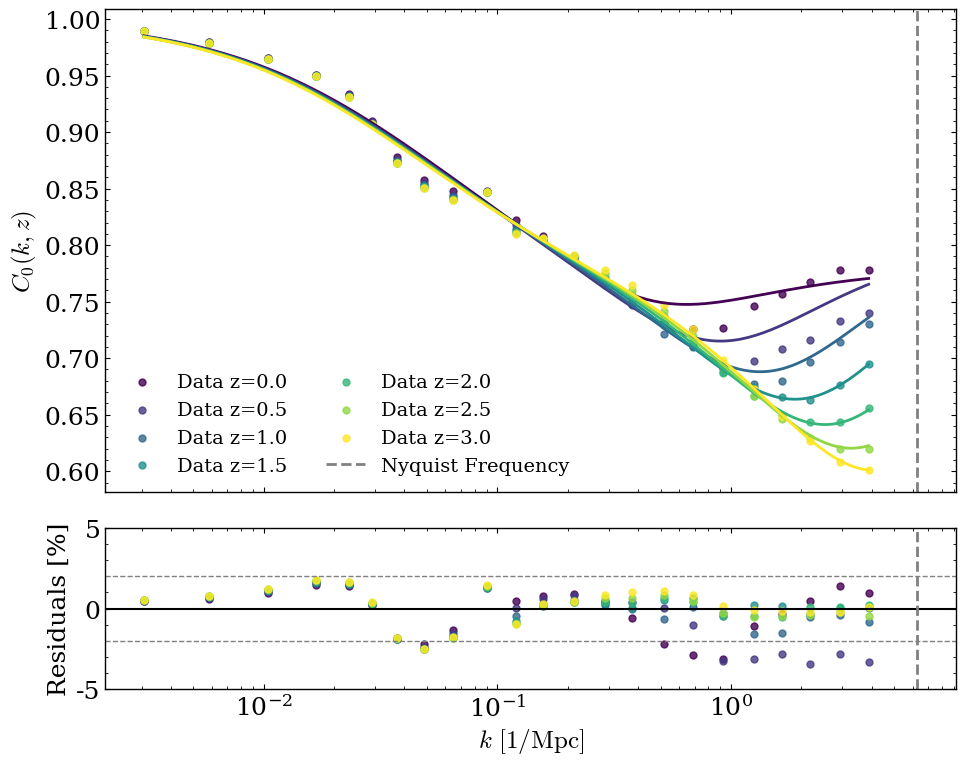

In [5]:
# =================================================================
# 5. UNIFIED PLOT (GLOBAL FIT)
# =================================================================
# Updated redshift list: 0.0 to 3.0 in increments of 0.5
z_list_plot = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

# Generate a continuous colormap for the 7 redshift slices
colors = plt.cm.viridis(np.linspace(0, 1, len(z_list_plot)))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0)

popt_global = np.array([19.3497, -0.0222, 2.3903, -4.2292, 100.4631, -3.4753, 24.5612, -0.0062, 9.7188, -0.7428, 128.7235, -3.5584])

for i, z in enumerate(z_list_plot):
    mask = z_global == z
    if not np.any(mask): continue
        
    k_val = k_global[mask]
    Ck_val = Ck_global[mask]
    
    k_cont = np.logspace(np.log10(k_global.min()), np.log10(k_global.max()), 200)
    
    # Model routing: Now using the Global Pade fit across all redshifts
    Ck_fit_at_data = pade_model(k_val, z, *popt_global)
    Ck_cont_fit = pade_model(k_cont, z, *popt_global)
    
    # Main Plot (Scatter + Line overlaid)
    ax1.scatter(k_val, Ck_val, color=colors[i], label=f'Data z={z}', s=25, alpha=0.8)
    ax1.plot(k_cont, Ck_cont_fit, color=colors[i], linestyle='-', lw=2)
    
    # Residuals Plot (Scatter only)
    resid = (Ck_val / Ck_fit_at_data - 1) * 100
    ax2.scatter(k_val, resid, color=colors[i], s=25, alpha=0.8)

ax1.set_xscale('log')
ax1.set_ylabel(r'$C_0(k, z)$')
ax1.axvline(k_nyquist, color='gray', lw=2, ls='--', label='Nyquist Frequency')
ax1.legend(ncol=2, loc='lower left')

ax2.set_ylabel('Residuals [%]')
ax2.set_xlabel(r'$k \ [1/\mathrm{Mpc}]$')
ax2.axhline(0, color='black', lw=1.5)
ax2.axhline(2, color='gray', lw=1, ls='--')
ax2.axhline(-2, color='gray', lw=1, ls='--')
ax2.axvline(k_nyquist, color='gray', lw=2, ls='--')
ax2.set_ylim(-5, 5)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Parameter Correlation Matrix (Global Fit)')

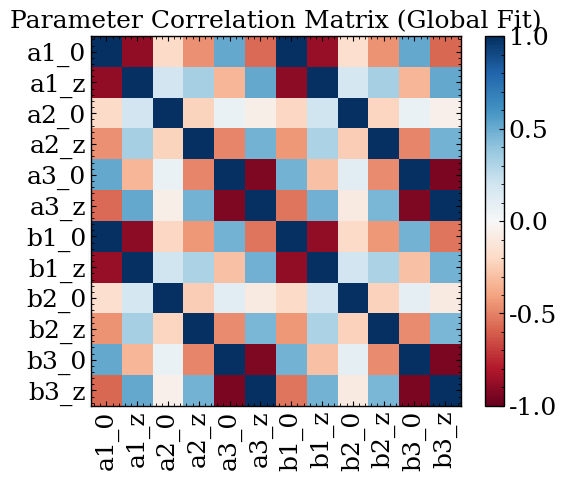

In [6]:
# Assuming popt, pcov = curve_fit(...)
perr = np.sqrt(np.diag(pcov_global))
corr_matrix = pcov_global / np.outer(perr, perr)

# Plot it
plt.imshow(corr_matrix, cmap='RdBu', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.title("Parameter Correlation Matrix (Global Fit)")

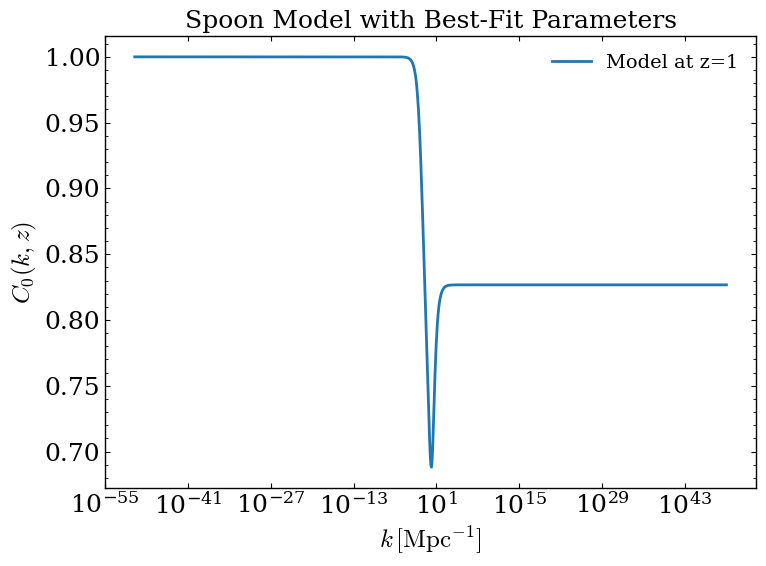

In [8]:
def test_C(k, z):
    Ck_test = pade_model(k_test, z, *popt_global)
    fig, ax = plt.subplots(figsize=(8,6))
    ax.semilogx(k_test, Ck_test, label=f'Model at z={z}')
    ax.set_xscale('log')
    ax.set_xlabel(r'$k\,[\mathrm{Mpc}^{-1}]$')
    ax.set_ylabel(r'$C_0(k, z)$')
    ax.set_title('Spoon Model with Best-Fit Parameters')
    ax.legend()
    plt.tight_layout()
    plt.show()

k_test = np.logspace(-50, 50, 1000)

test_C(k_test, 1)

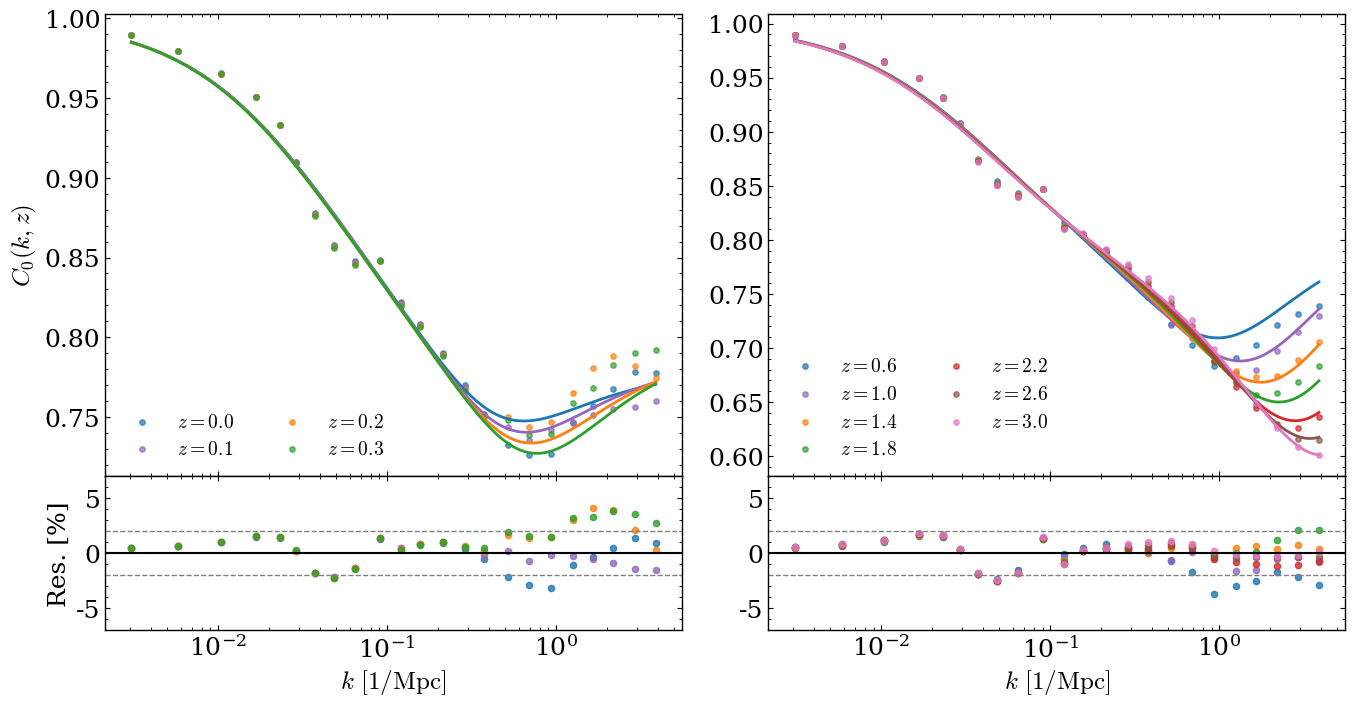

In [8]:
# Set up outer figure (1 row, 2 columns) for side-by-side plots
fig = plt.figure(figsize=(16, 8))
outer_gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.15)

# Group the configurations to loop through
z_lists = [
    [0.0, 0.1, 0.2, 0.3],                             # Left panel (Low z)
    [0.6, 1.0, 1.4, 1.8, 2.2, 2.6, 3.0]               # Right panel (High z)
]
titles = [r'$C_0(k, z)$ - Low $z$', r'$C_0(k, z)$ - High $z$']
colors = ['tab:blue', 'tab:purple', 'tab:orange', 'tab:green', 'tab:red', 'tab:brown', 'tab:pink', 'tab:gray']

for col in range(2):
    # Inner grid for main + residual (Height ratio 3:1)
    inner_gs = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[0, col], 
                                                height_ratios=[3, 1], hspace=0.0)
    
    ax1 = fig.add_subplot(inner_gs[0])
    ax2 = fig.add_subplot(inner_gs[1], sharex=ax1)
    
    z_list_plot = z_lists[col]
    
    for i, z in enumerate(z_list_plot):
        mask = z_global == z
        if not np.any(mask): continue
            
        k_val = k_global[mask]
        Ck_val = Ck_global[mask]
        k_cont = np.logspace(np.log10(k_global.min()), np.log10(k_global.max()), 200)
        
        # Route to the correct model and parameter set based on z
        Ck_fit = pade_model(k_val, z, *popt_global)
        Ck_cont_fit = pade_model(k_cont, z, *popt_global)
            
        # Main Plot
        ax1.scatter(k_val, Ck_val, color=colors[i], label=f'$z={z}$', s=15, alpha=0.7)
        ax1.plot(k_cont, Ck_cont_fit, color=colors[i], linestyle='-', lw=2)
        
        # Residuals Plot    
        resid = (Ck_val / Ck_fit - 1) * 100
        ax2.scatter(k_val, resid, color=colors[i], s=20, alpha=0.8)

    # --- Formatting Top Panel (ax1) ---
    ax1.set_xscale('log')
    
    if col == 0:  # Only add y-label to the leftmost plot
        ax1.set_ylabel(r'$C_0(k, z)$')
        
    plt.setp(ax1.get_xticklabels(), visible=False) # Hide x-ticks on top panel
    
    # Clean up legend so we don't duplicate the Nyquist label
    handles, labels = ax1.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax1.legend(by_label.values(), by_label.keys(), ncol=2, loc='lower left')

    # --- Formatting Bottom Panel (ax2) ---
    ax2.axhline(0, color='black', lw=1.5, ls='-')
    ax2.axhline(2, color='gray', lw=1, ls='--')
    ax2.axhline(-2, color='gray', lw=1, ls='--')
    
    ax2.set_xlabel(r'$k \ [1/\mathrm{Mpc}]$')
    
    if col == 0:  # Only add y-label to the leftmost plot
        ax2.set_ylabel('Res. [%]')
        
    ax2.set_ylim(-7, 7) 
    ax2.set_yticks([-5, 0, 5])
    
    # Prune the highest tick mark to prevent overlap with the main plot!
    # ax2.yaxis.set_major_locator(MaxNLocator(prune='upper'))

# plt.savefig('baseline_fits_padé.pdf', bbox_inches='tight')
plt.show()